# 04 — Post-hoc XAI: SHAP & LIME

**Explainable Fraud Detection and Investigation Platform**  
**MIA 5100 machine-learning model with an MIA 5126 XAI extension**

This notebook applies the post-hoc explanation methods introduced in **MIA 5126 — Essential Concepts in Data Science** to the frozen fraud model developed in Notebooks 01–03. It adds global and local transparency without retraining the model or changing its operating threshold.

## Deliverables

- Global SHAP bar and beeswarm plots
- SHAP dependence scatter plots
- Local SHAP waterfall explanations for representative TP, FP, FN, and TN cases
- LIME explanations for the same cases
- SHAP/LIME comparison with local-fidelity diagnostics
- Machine-readable XAI artifacts for the FastAPI and Streamlit applications
- Explicit explanation limitations and human-review boundaries

> **Experimental discipline:** The champion model, preprocessing schema, and threshold are already frozen. SHAP and LIME are used only for post-hoc reporting. No explanation in this notebook may be used to select features, retrain a model, alter hyperparameters, or change the threshold using final-test information.

> **Interpretation boundary:** A contribution describes how the frozen model behaves for the supplied processed features. It is not evidence that a feature caused fraud, and it does not prove that a transaction is fraudulent or legitimate.

In [1]:
from pathlib import Path
from importlib.metadata import version
from IPython.display import Markdown, display

import json
import os
import platform
import re
import time
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap

from lime.lime_tabular import LimeTabularExplainer
from scipy.stats import spearmanr

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)

RANDOM_STATE = 42
SHAP_BACKGROUND_ROWS = 100
SHAP_GLOBAL_ROWS = 1_000
LIME_REFERENCE_ROWS = 10_000
LIME_NUM_SAMPLES = 5_000
LOCAL_TOP_FEATURES = 20
DISPLAY_TOP_FEATURES = 15

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__}")
print(f"SHAP: {shap.__version__}")
print(f"LIME: {version('lime')}")

Python: 3.11.15
pandas: 3.0.3
SHAP: 0.51.0
LIME: 0.2.0.1


In [2]:
def find_project_root(start=None):
    candidate = Path(start or Path.cwd()).resolve()
    for parent in [candidate, *candidate.parents]:
        if (parent / "notebooks").exists() and (parent / "models").exists():
            return parent
    raise FileNotFoundError("Could not locate the project repository.")


PROJECT_ROOT = find_project_root()
PROCESSED_PATH = PROJECT_ROOT / "data" / "processed"
TRAINED_MODEL_PATH = PROJECT_ROOT / "models" / "trained"
MODEL_RESULTS_PATH = PROJECT_ROOT / "results" / "model_comparison"
XAI_RESULTS_PATH = PROJECT_ROOT / "results" / "xai"
XAI_FIGURES_PATH = XAI_RESULTS_PATH / "figures"
REPORTS_PATH = PROJECT_ROOT / "reports"

for path in [XAI_RESULTS_PATH, XAI_FIGURES_PATH, REPORTS_PATH]:
    path.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"XAI output path: {XAI_RESULTS_PATH}")

Project root: /Users/hshazel/Projects/explainable-fraud-investigation-platform
XAI output path: /Users/hshazel/Projects/explainable-fraud-investigation-platform/results/xai


## 1. Load the frozen model and processed reporting data

The notebook loads the saved champion manifest rather than selecting a model again. The processed test matrix is used only for final post-hoc reporting, while a fixed sample of training rows supplies the SHAP background and LIME reference distribution.

In [3]:
manifest = json.loads(
    (TRAINED_MODEL_PATH / "champion_manifest.json").read_text(encoding="utf-8")
)
model = joblib.load(TRAINED_MODEL_PATH / manifest["model_file"])
model_metadata = json.loads(
    (TRAINED_MODEL_PATH / manifest["metadata_file"]).read_text(encoding="utf-8")
)

X_train = pd.read_parquet(PROCESSED_PATH / "X_train.parquet")
X_test = pd.read_parquet(PROCESSED_PATH / "X_test.parquet")
y_test = pd.read_parquet(PROCESSED_PATH / "y_test.parquet")["isFraud"].reset_index(drop=True)
id_test = pd.read_parquet(PROCESSED_PATH / "id_test.parquet")["TransactionID"].reset_index(drop=True)

threshold = float(model_metadata["decision_threshold"])
feature_names = list(model.feature_names_in_)

predictions = pd.read_parquet(MODEL_RESULTS_PATH / "champion_predictions.parquet")
test_predictions = predictions.loc[predictions["split"] == "test"].copy()
conditions = [
    (test_predictions["isFraud"] == 1) & (test_predictions["predicted_fraud"] == 1),
    (test_predictions["isFraud"] == 0) & (test_predictions["predicted_fraud"] == 1),
    (test_predictions["isFraud"] == 1) & (test_predictions["predicted_fraud"] == 0),
]
test_predictions["Outcome"] = np.select(
    conditions,
    ["True positive", "False positive", "False negative"],
    default="True negative",
)


def select_representative_case(frame, outcome):
    subset = frame.loc[frame["Outcome"] == outcome].copy()
    median_score = subset["fraud_risk_score"].median()
    subset["Distance to outcome median"] = (
        subset["fraud_risk_score"] - median_score
    ).abs()
    return subset.sort_values(
        ["Distance to outcome median", "TransactionID"]
    ).iloc[0]


outcome_order = ["True positive", "False positive", "False negative", "True negative"]
selected_cases = pd.DataFrame([
    select_representative_case(test_predictions, outcome)
    for outcome in outcome_order
])


def feature_family(feature):
    if feature in {"TransactionDT", "TransactionAmt", "TransactionHour", "TransactionDay"}:
        return "Transaction"
    if feature.startswith("card") or "CardID" in feature:
        return "Card"
    if feature.startswith("addr") or feature.startswith("dist"):
        return "Address / distance"
    if re.fullmatch(r"C\d+", feature):
        return "Count (C)"
    if re.fullmatch(r"D\d+", feature):
        return "Time delta (D)"
    if re.fullmatch(r"M\d+.*", feature):
        return "Match flag (M)"
    if re.fullmatch(r"V\d+", feature):
        return "Anonymous V"
    if feature.startswith("id_"):
        return "Identity"
    if "email" in feature.lower():
        return "Email"
    if "device" in feature.lower():
        return "Device"
    if feature.startswith("ProductCD"):
        return "Product"
    return "Engineered / other"


gain_scores = model.get_booster().get_score(importance_type="gain")
native_importance = pd.DataFrame({"Feature": feature_names})
native_importance["Gain"] = native_importance["Feature"].map(gain_scores).fillna(0.0)
native_importance["Normalized Gain"] = (
    native_importance["Gain"] / native_importance["Gain"].sum()
)
native_importance = native_importance.sort_values(
    "Normalized Gain", ascending=False
).reset_index(drop=True)
native_importance["Gain Rank"] = np.arange(1, len(native_importance) + 1)
native_importance["Feature family"] = native_importance["Feature"].map(feature_family)

assert manifest["model_name"] == "XGBoost (tuned)"
assert X_train.columns.tolist() == feature_names
assert X_test.columns.tolist() == feature_names
assert len(feature_names) == int(model_metadata["feature_count"]) == 359
assert len(X_test) == len(y_test) == len(id_test)
assert id_test.is_unique
assert set(selected_cases["TransactionID"]).issubset(set(id_test))

display(Markdown(
    f"**Frozen champion:** {manifest['model_name']}  \n"
    f"**Decision threshold:** {threshold:.6f}  \n"
    f"**Processed features:** {len(feature_names):,}  \n"
    f"**Test rows available for reporting:** {len(X_test):,}"
))

**Frozen champion:** XGBoost (tuned)  
**Decision threshold:** 0.275698  
**Processed features:** 359  
**Test rows available for reporting:** 88,581

In [4]:
id_to_position = pd.Series(
    np.arange(len(id_test), dtype="int64"), index=id_test.to_numpy()
)
selected_case_ids = selected_cases["TransactionID"].astype("int64").tolist()
local_positions = [int(id_to_position.loc[transaction_id]) for transaction_id in selected_case_ids]
local_features = X_test.iloc[local_positions].reset_index(drop=True)

saved_scores = selected_cases.set_index("TransactionID").loc[
    selected_case_ids, "fraud_risk_score"
].to_numpy()
recomputed_scores = model.predict_proba(local_features)[:, 1]
np.testing.assert_allclose(recomputed_scores, saved_scores, rtol=1e-5, atol=1e-6)

case_context = selected_cases.set_index("TransactionID").loc[
    selected_case_ids,
    ["Outcome", "fraud_risk_score", "predicted_fraud", "isFraud"],
].reset_index()
display(case_context.style.format({
    "fraud_risk_score": "{:.4f}",
}))
print("Representative case scores match the frozen predictions from Notebook 03 (ML Model Selection, Tuning & Evaluation).")

,TransactionID,Outcome,fraud_risk_score,predicted_fraud,isFraud
0,3519397,True positive,0.8880,1,1
1,3524909,False positive,0.4169,1,0
2,3551357,False negative,0.0993,0,1
3,3541077,True negative,0.0192,0,0


Representative case scores match the frozen predictions from Notebook 03 (ML Model Selection, Tuning & Evaluation).


## 2. Fixed explanation samples

- **SHAP background:** 100 training rows, consistent with the documented 100–1,000 row interventional background guidance.
- **Global SHAP reporting sample:** 1,000 randomly selected test rows. This is a reproducible approximation of global behavior, not a new evaluation sample.
- **Local cases:** One median-risk test case from each confusion-matrix outcome (true positive, false positive, false negative, and true negative), selected deterministically from Notebook 03 predictions.
- **LIME reference:** 10,000 training rows to estimate perturbation distributions without densifying all 413,378 training observations.

In [5]:
rng = np.random.default_rng(RANDOM_STATE)
background_positions = np.sort(
    rng.choice(len(X_train), size=SHAP_BACKGROUND_ROWS, replace=False)
)
global_positions = np.sort(
    rng.choice(len(X_test), size=SHAP_GLOBAL_ROWS, replace=False)
)

shap_background = X_train.iloc[background_positions].copy()
global_features = X_test.iloc[global_positions].copy()
global_ids = id_test.iloc[global_positions].reset_index(drop=True)
global_labels = y_test.iloc[global_positions].reset_index(drop=True)

sample_manifest = pd.DataFrame({
    "TransactionID": global_ids,
    "isFraud": global_labels.astype("int8"),
    "TestRowPosition": global_positions,
})

print(f"SHAP background rows: {len(shap_background):,}")
print(f"Global SHAP reporting rows: {len(global_features):,}")
print(f"Global sample fraud rate: {global_labels.mean():.2%}")
print(f"Local representative cases: {len(local_features):,}")

SHAP background rows: 100
Global SHAP reporting rows: 1,000
Global sample fraud rate: 3.70%
Local representative cases: 4


## 3. Tree SHAP in model-score space

`TreeExplainer` is model-specific and efficient for the XGBoost champion. The explainer uses an interventional training background and `model_output="probability"`, so the base value plus feature contributions reconstructs the model's `predict_proba` class-1 output.

The output is still described as an **uncalibrated fraud risk score**, consistent with Notebook 03 (**ML Model Selection, Tuning & Evaluation**). It must not be interpreted as an empirically calibrated probability of fraud.

In [6]:
shap_start = time.time()
tree_explainer = shap.TreeExplainer(
    model,
    data=shap_background,
    feature_perturbation="interventional",
    model_output="probability",
)
global_shap = tree_explainer(global_features, check_additivity=False)
local_shap = tree_explainer(local_features, check_additivity=False)
shap_seconds = time.time() - shap_start


def reconstructed_output(explanation):
    base = np.asarray(explanation.base_values, dtype=float)
    if base.ndim == 0:
        base = np.repeat(base, len(explanation.values))
    return base + np.asarray(explanation.values).sum(axis=1)


global_reconstructed = reconstructed_output(global_shap)
local_reconstructed = reconstructed_output(local_shap)
global_model_scores = model.predict_proba(global_features)[:, 1]
local_model_scores = model.predict_proba(local_features)[:, 1]

global_reconstruction_error = float(
    np.max(np.abs(global_reconstructed - global_model_scores))
)
local_reconstruction_error = float(
    np.max(np.abs(local_reconstructed - local_model_scores))
)

assert global_shap.shape == global_features.shape
assert local_shap.shape == local_features.shape
assert global_reconstruction_error < 1e-5
assert local_reconstruction_error < 1e-5

print(f"SHAP computation time: {shap_seconds:.2f} seconds")
print(f"Maximum global reconstruction error: {global_reconstruction_error:.2e}")
print(f"Maximum local reconstruction error: {local_reconstruction_error:.2e}")
print(f"SHAP base risk score: {float(np.asarray(global_shap.base_values)[0]):.4f}")

 65%|=============       | 646/1000 [00:11<00:06]       

 71%|==============      | 707/1000 [00:12<00:04]       

 77%|===============     | 769/1000 [00:13<00:03]       

 83%|=================   | 832/1000 [00:14<00:02]       

 90%|==================  | 895/1000 [00:15<00:01]       

 95%|=================== | 951/1000 [00:16<00:00]       

SHAP computation time: 16.89 seconds
Maximum global reconstruction error: 3.82e-07
Maximum local reconstruction error: 1.53e-07
SHAP base risk score: 0.1504


## 4. Global SHAP explanations

In [7]:
global_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean absolute SHAP": np.abs(global_shap.values).mean(axis=0),
    "Mean signed SHAP": global_shap.values.mean(axis=0),
    "Positive contribution share": (global_shap.values > 0).mean(axis=0),
}).sort_values("Mean absolute SHAP", ascending=False).reset_index(drop=True)

global_importance["SHAP rank"] = np.arange(1, len(global_importance) + 1)
total_shap = global_importance["Mean absolute SHAP"].sum()
global_importance["Normalized mean absolute SHAP"] = (
    global_importance["Mean absolute SHAP"] / total_shap
)

native_columns = native_importance[[
    "Feature", "Normalized Gain", "Gain Rank", "Feature family"
]].copy()
global_importance = global_importance.merge(
    native_columns, on="Feature", how="left", validate="one_to_one"
)

display(global_importance.head(20).style.format({
    "Mean absolute SHAP": "{:.5f}",
    "Mean signed SHAP": "{:+.5f}",
    "Positive contribution share": "{:.1%}",
    "Normalized mean absolute SHAP": "{:.2%}",
    "Normalized Gain": "{:.2%}",
}))

,Feature,Mean absolute SHAP,Mean signed SHAP,Positive contribution share,SHAP rank,Normalized mean absolute SHAP,Normalized Gain,Gain Rank,Feature family
0,TransactionDT,0.03664,-0.03658,0.3%,1,9.06%,0.20%,127,Transaction
1,C13,0.02640,-0.00288,34.9%,2,6.53%,0.54%,19,Count (C)
2,C1,0.02375,+0.00253,31.9%,3,5.87%,0.55%,18,Count (C)
3,TransactionAmt,0.01434,+0.00024,43.6%,4,3.55%,0.21%,104,Transaction
4,CardID_Frequency,0.01184,-0.00253,45.9%,5,2.93%,0.22%,99,Card
5,card6_credit,0.01147,-0.00112,29.2%,6,2.84%,0.73%,11,Card
6,P_emaildomain_Frequency,0.00999,+0.00072,69.7%,7,2.47%,0.23%,91,Email
7,card1,0.00937,-0.00103,44.2%,8,2.32%,0.19%,138,Card
8,V69,0.00932,-0.00123,64.3%,9,2.31%,4.73%,2,Anonymous V
9,C5,0.00931,-0.00207,60.8%,10,2.30%,0.67%,13,Count (C)


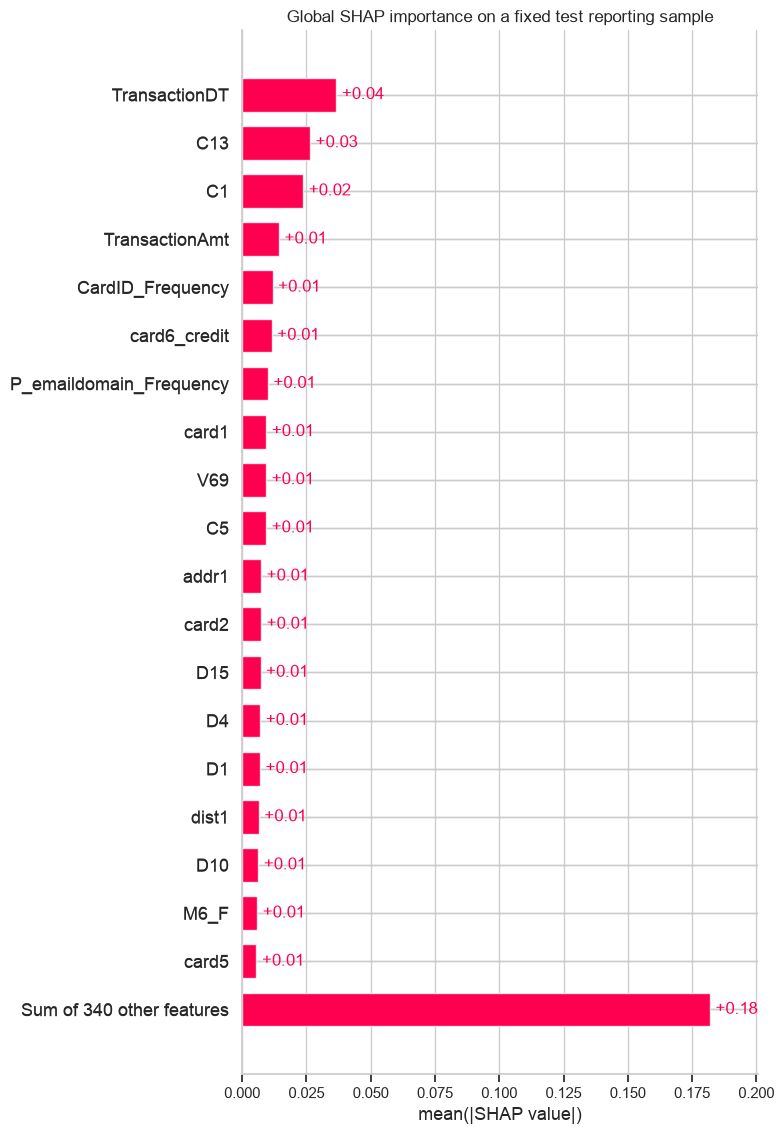

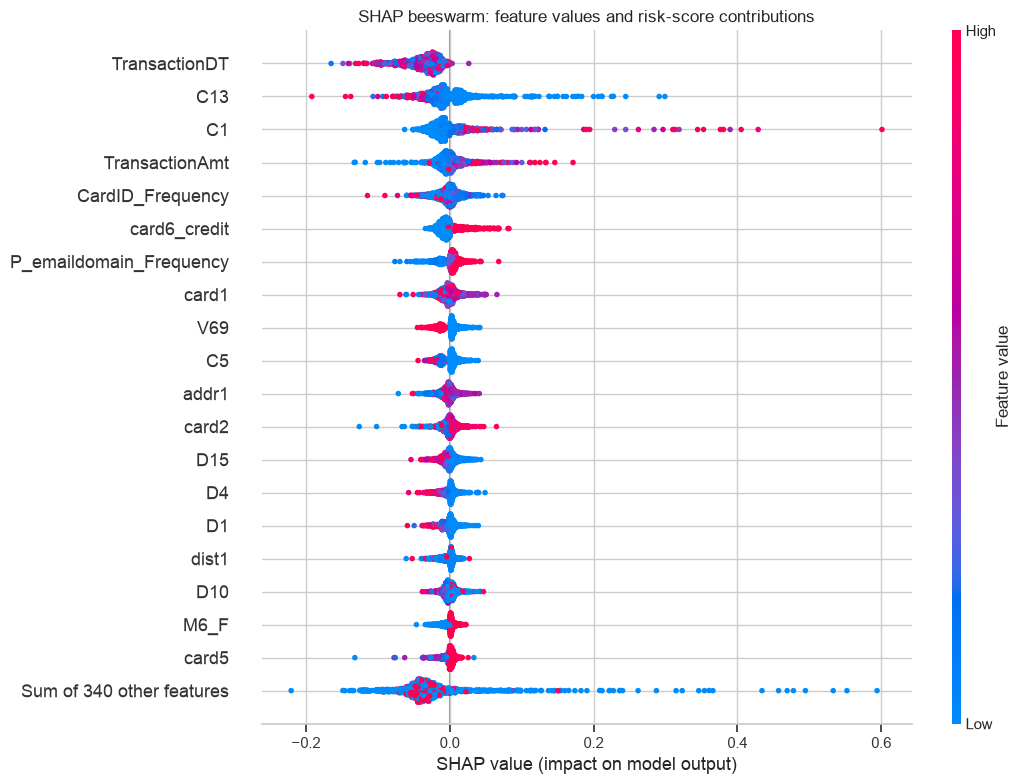

Saved: shap_global_bar.png, shap_global_beeswarm.png


In [8]:
shap.plots.bar(global_shap, max_display=20, show=False)
plt.title("Global SHAP importance on a fixed test reporting sample")
plt.tight_layout()
global_bar_file = XAI_FIGURES_PATH / "shap_global_bar.png"
plt.savefig(global_bar_file, dpi=180, bbox_inches="tight")
plt.show()

shap.plots.beeswarm(
    global_shap,
    max_display=20,
    show=False,
    plot_size=(11, 8),
)
plt.title("SHAP beeswarm: feature values and risk-score contributions")
plt.tight_layout()
global_beeswarm_file = XAI_FIGURES_PATH / "shap_global_beeswarm.png"
plt.savefig(global_beeswarm_file, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved: {global_bar_file.name}, {global_beeswarm_file.name}")

### SHAP versus XGBoost native gain

Native gain measures training-time split improvement. Mean absolute SHAP measures average prediction impact on the fixed reporting sample. Agreement is useful context, but the rankings are not expected to be identical because they answer different questions.

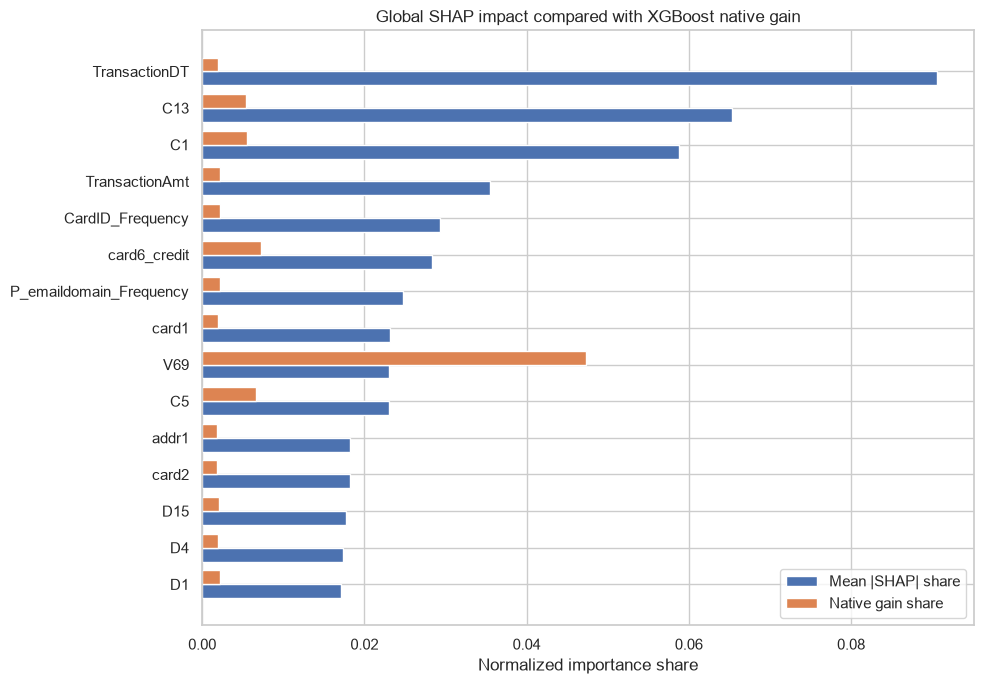

Spearman rank correlation across features: 0.621


In [9]:
rank_correlation = spearmanr(
    global_importance["SHAP rank"],
    global_importance["Gain Rank"],
    nan_policy="omit",
)
spearman_rank_correlation = float(rank_correlation.statistic)

comparison_features = global_importance.head(15).copy().sort_values(
    "Normalized mean absolute SHAP"
)
positions = np.arange(len(comparison_features))
height = 0.38

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    positions - height / 2,
    comparison_features["Normalized mean absolute SHAP"],
    height,
    label="Mean |SHAP| share",
)
ax.barh(
    positions + height / 2,
    comparison_features["Normalized Gain"],
    height,
    label="Native gain share",
)
ax.set_yticks(positions, comparison_features["Feature"])
ax.set_xlabel("Normalized importance share")
ax.set_title("Global SHAP impact compared with XGBoost native gain")
ax.legend()
plt.tight_layout()
importance_comparison_file = XAI_FIGURES_PATH / "shap_vs_native_importance.png"
plt.savefig(importance_comparison_file, dpi=180, bbox_inches="tight")
plt.show()

print(f"Spearman rank correlation across features: {spearman_rank_correlation:.3f}")

### SHAP dependence scatter plots

Each plot relates a processed feature value to that feature's SHAP contribution across the fixed reporting sample. The vertical axis is the change in the model's uncalibrated risk score relative to the background expectation. Patterns are associative descriptions of model behavior, not causal effects.

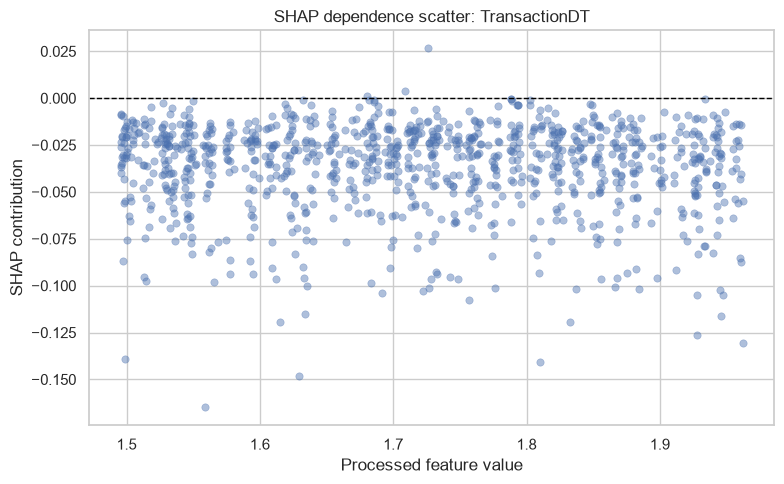

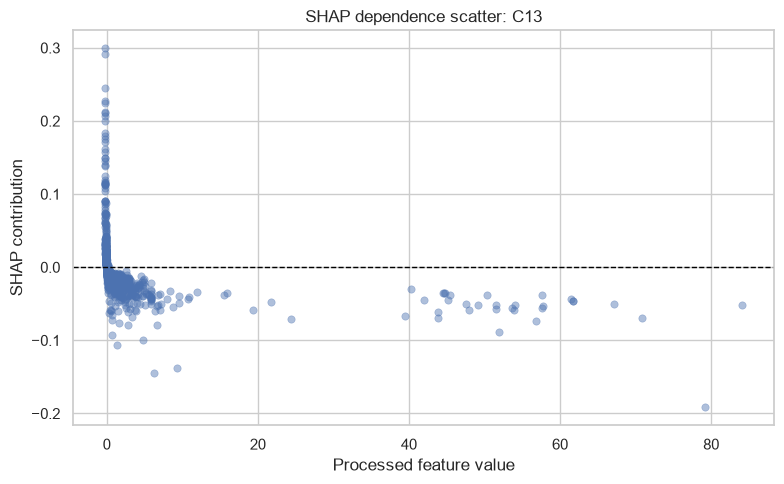

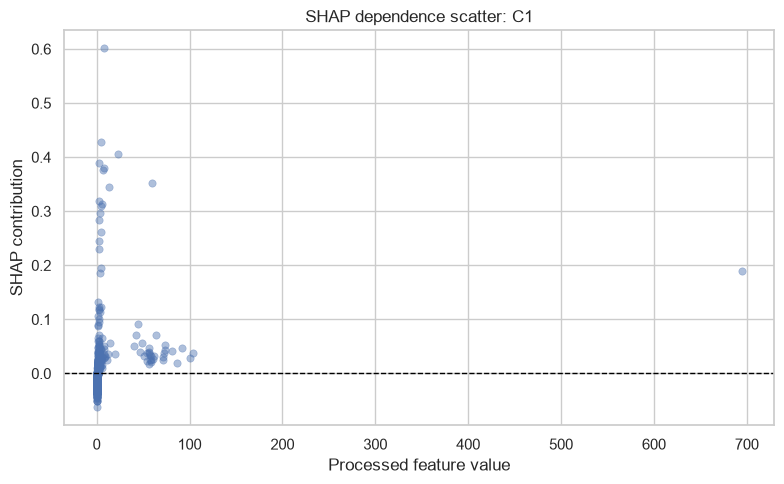

Dependence features: ['TransactionDT', 'C13', 'C1']


In [10]:
dependence_features = global_importance.head(3)["Feature"].tolist()
dependence_figure_files = {}

for feature in dependence_features:
    feature_index = feature_names.index(feature)
    plot_data = pd.DataFrame({
        "Processed feature value": global_features[feature].to_numpy(),
        "SHAP contribution": global_shap.values[:, feature_index],
    })
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.scatterplot(
        data=plot_data,
        x="Processed feature value",
        y="SHAP contribution",
        alpha=0.45,
        s=28,
        edgecolor=None,
        ax=ax,
    )
    ax.axhline(0, color="black", linewidth=1, linestyle="--")
    ax.set_title(f"SHAP dependence scatter: {feature}")
    plt.tight_layout()
    safe_name = re.sub(r"[^A-Za-z0-9_-]+", "_", feature)
    figure_file = XAI_FIGURES_PATH / f"shap_dependence_{safe_name}.png"
    plt.savefig(figure_file, dpi=180, bbox_inches="tight")
    plt.show()
    dependence_figure_files[feature] = figure_file.name

print(f"Dependence features: {dependence_features}")

## 5. Local SHAP waterfall explanations

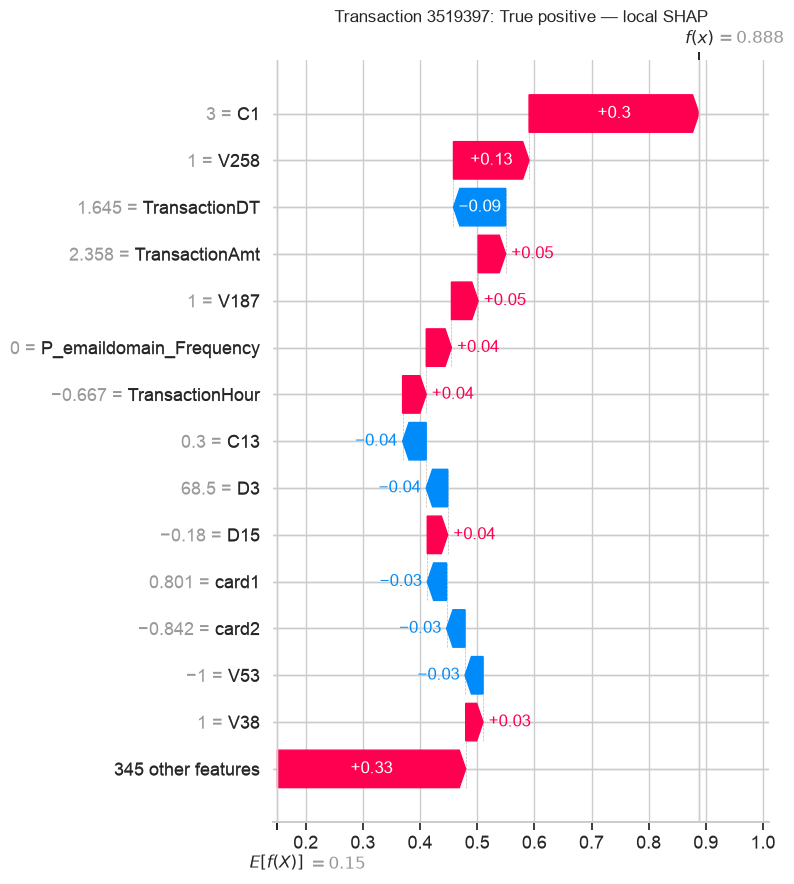

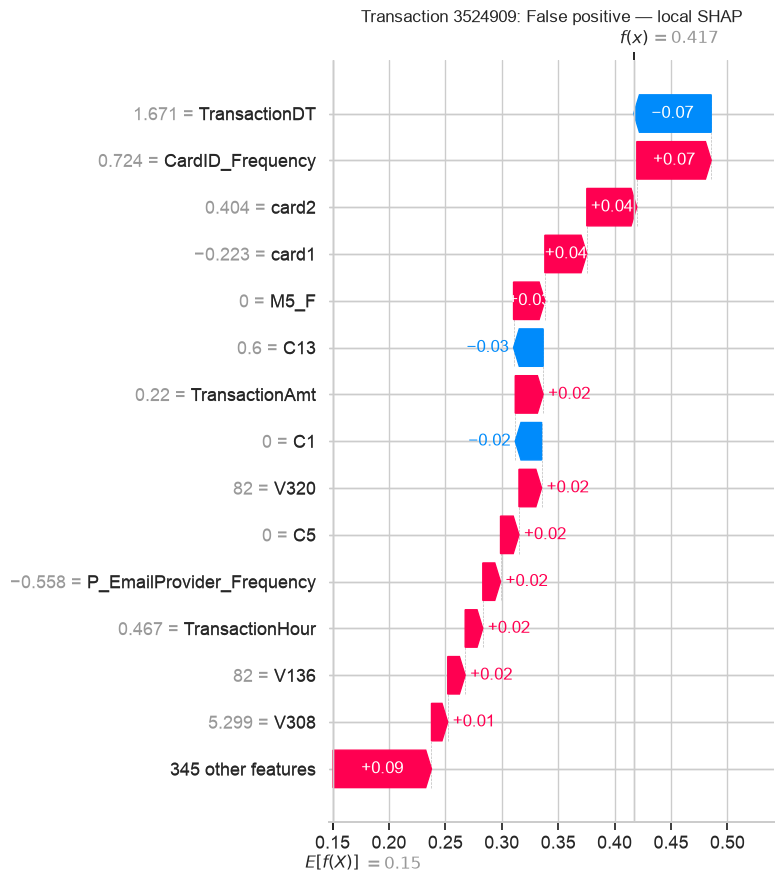

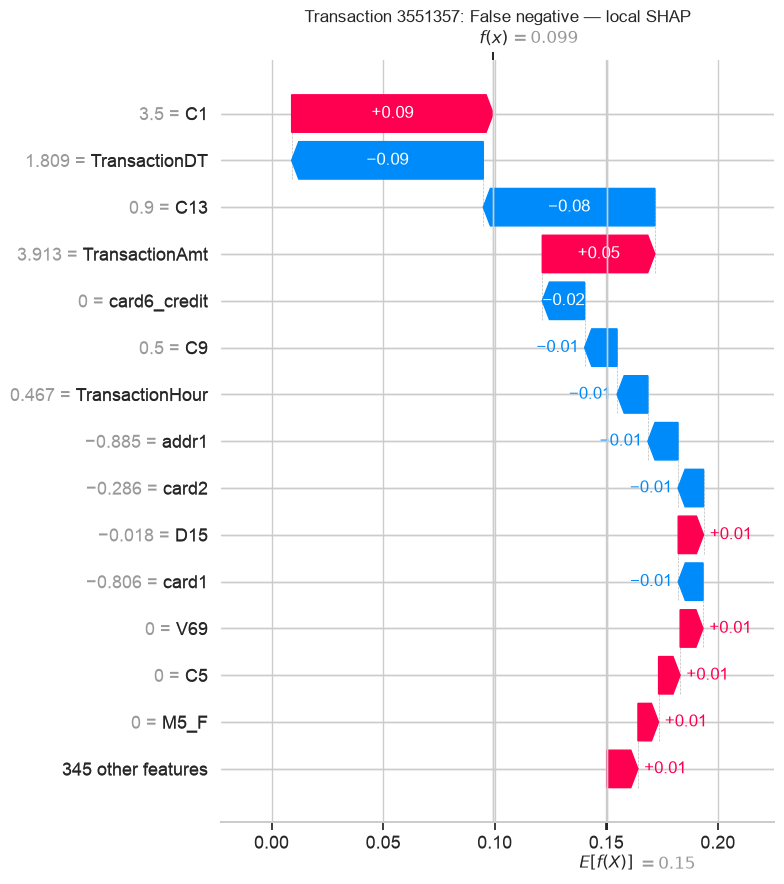

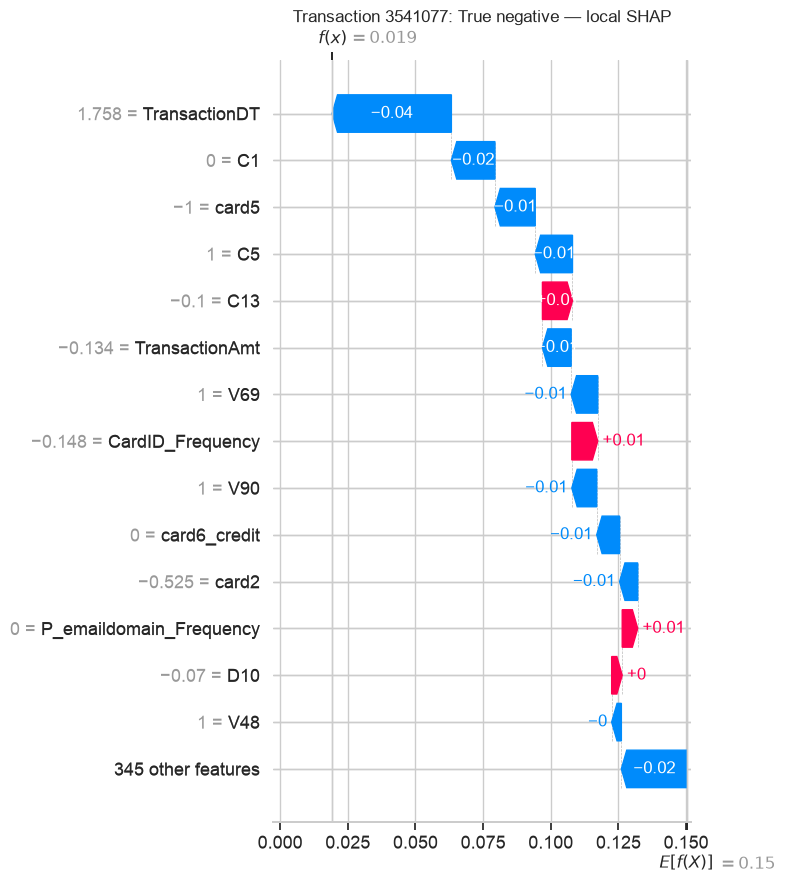

,TransactionID,Feature,Processed feature value,SHAP contribution,Absolute SHAP contribution,Direction,Rank,Base risk score,Model risk score,Decision threshold
0,3519397,C1,3.0000,+0.29729,0.29729,Higher risk score,1,0.1504,0.8880,0.2757
1,3519397,V258,1.0000,+0.13230,0.13230,Higher risk score,2,0.1504,0.8880,0.2757
2,3519397,TransactionDT,1.6452,-0.09135,0.09135,Lower risk score,3,0.1504,0.8880,0.2757
3,3519397,TransactionAmt,2.3577,+0.04814,0.04814,Higher risk score,4,0.1504,0.8880,0.2757
4,3519397,V187,1.0000,+0.04677,0.04677,Higher risk score,5,0.1504,0.8880,0.2757
5,3519397,P_emaildomain_Frequency,0.0000,+0.04410,0.04410,Higher risk score,6,0.1504,0.8880,0.2757
6,3519397,TransactionHour,-0.6667,+0.04130,0.04130,Higher risk score,7,0.1504,0.8880,0.2757
7,3519397,C13,0.3000,-0.04122,0.04122,Lower risk score,8,0.1504,0.8880,0.2757
8,3519397,D3,68.5000,-0.03771,0.03771,Lower risk score,9,0.1504,0.8880,0.2757
9,3519397,D15,-0.1798,+0.03583,0.03583,Higher risk score,10,0.1504,0.8880,0.2757


In [11]:
local_shap_records = []
shap_waterfall_files = {}

for case_index, transaction_id in enumerate(selected_case_ids):
    context = case_context.loc[
        case_context["TransactionID"] == transaction_id
    ].iloc[0]
    values = np.asarray(local_shap.values[case_index])
    absolute_order = np.argsort(np.abs(values))[::-1]

    for rank, feature_index in enumerate(absolute_order, start=1):
        contribution = float(values[feature_index])
        local_shap_records.append({
            "TransactionID": int(transaction_id),
            "Feature": feature_names[feature_index],
            "Processed feature value": float(local_features.iloc[case_index, feature_index]),
            "SHAP contribution": contribution,
            "Absolute SHAP contribution": abs(contribution),
            "Direction": (
                "Higher risk score" if contribution > 0
                else "Lower risk score" if contribution < 0
                else "Neutral"
            ),
            "Rank": rank,
            "Base risk score": float(np.asarray(local_shap.base_values)[case_index]),
            "Model risk score": float(local_model_scores[case_index]),
            "Decision threshold": threshold,
        })

    shap.plots.waterfall(
        local_shap[case_index],
        max_display=DISPLAY_TOP_FEATURES,
        show=False,
    )
    plt.title(
        f"Transaction {transaction_id}: {context['Outcome']} — local SHAP"
    )
    plt.tight_layout()
    figure_file = XAI_FIGURES_PATH / f"shap_waterfall_{transaction_id}.png"
    plt.savefig(figure_file, dpi=180, bbox_inches="tight")
    plt.show()
    shap_waterfall_files[str(transaction_id)] = figure_file.name

local_shap_table = pd.DataFrame(local_shap_records)
display(
    local_shap_table.query("Rank <= 10").style.format({
        "Processed feature value": "{:.4f}",
        "SHAP contribution": "{:+.5f}",
        "Absolute SHAP contribution": "{:.5f}",
        "Base risk score": "{:.4f}",
        "Model risk score": "{:.4f}",
        "Decision threshold": "{:.4f}",
    })
)

## 6. LIME explanations for the same cases

LIME is model-agnostic. It perturbs a processed transaction and fits a sparse local linear surrogate around that case. The displayed weights describe the surrogate, not XGBoost directly.

The local surrogate's weighted R² (`LIME local fidelity R2`) is reported for every case. Low fidelity means the linear approximation does not closely reproduce the nonlinear champion in that neighborhood; its feature weights should then receive limited evidentiary weight.

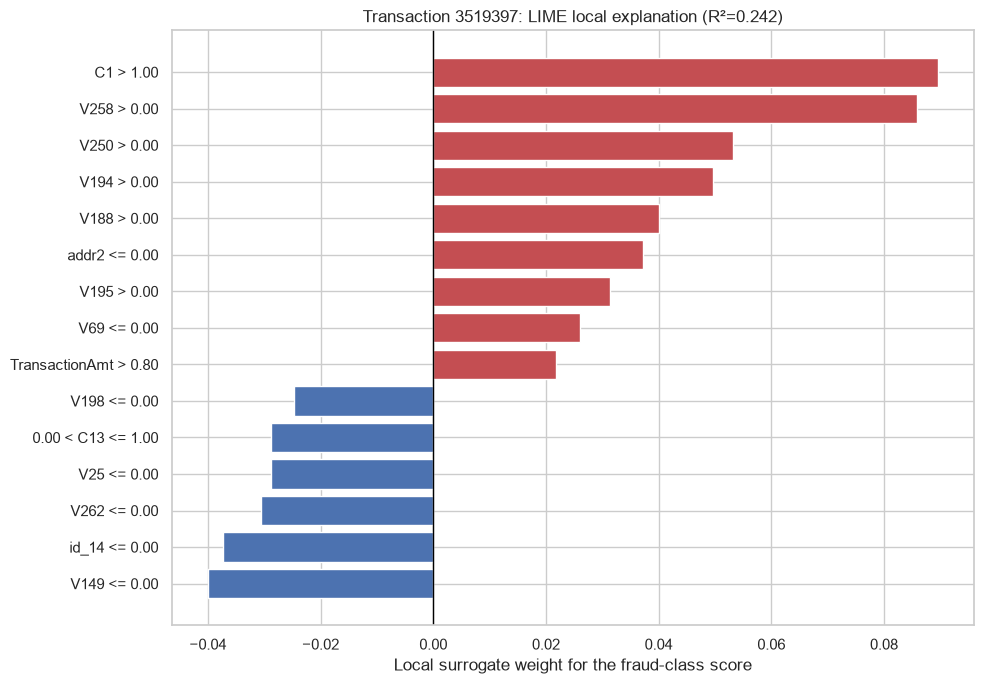

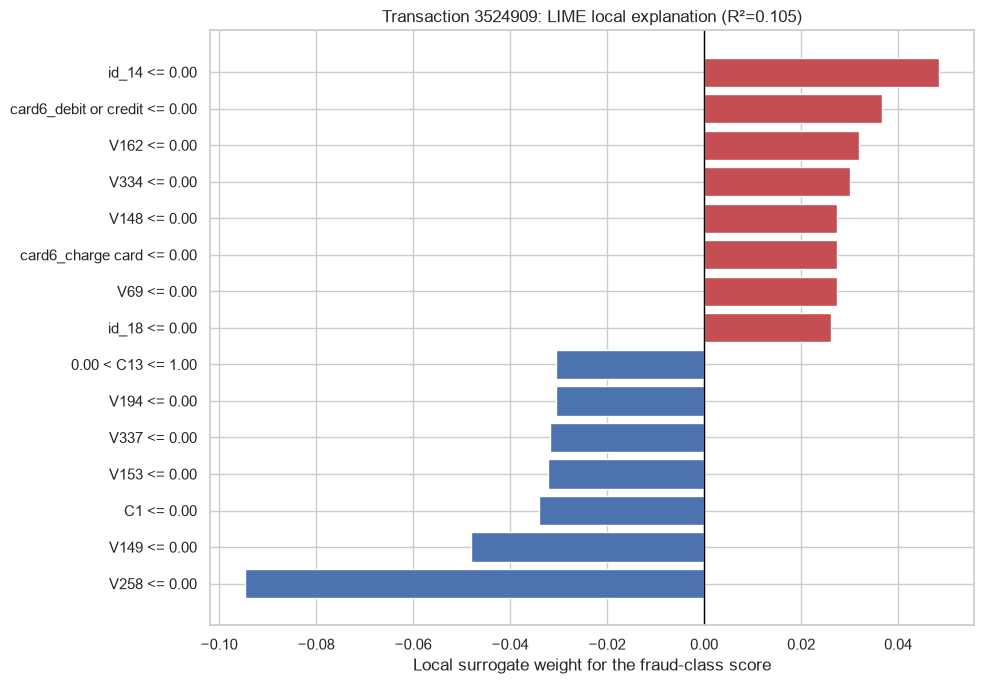

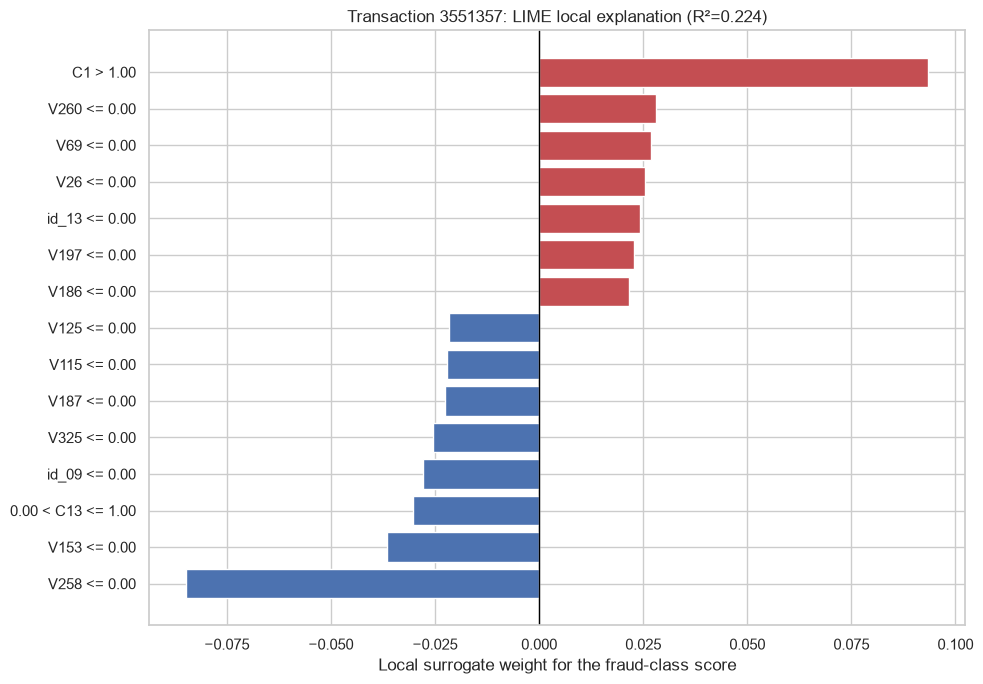

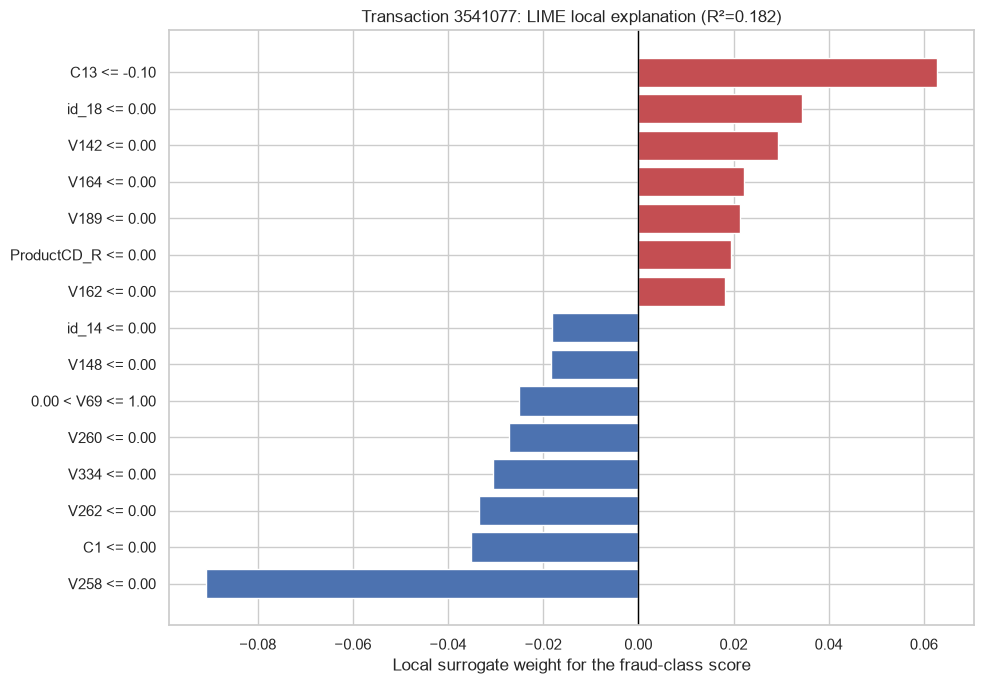

,TransactionID,LIME local fidelity R2,LIME local prediction,Model risk score,Absolute local prediction error
0,3519397,0.242,0.3961,0.8880,0.4919
1,3524909,0.105,0.0164,0.4169,0.4005
2,3551357,0.224,0.1046,0.0993,0.0052
3,3541077,0.182,0.0498,0.0192,0.0306


LIME computation time: 1.36 seconds


In [12]:
lime_reference = X_train.sample(
    n=min(LIME_REFERENCE_ROWS, len(X_train)),
    random_state=RANDOM_STATE,
)
lime_explainer = LimeTabularExplainer(
    lime_reference.to_numpy(),
    feature_names=feature_names,
    class_names=["Non-fraud class", "Fraud class"],
    mode="classification",
    discretize_continuous=True,
    random_state=RANDOM_STATE,
)

lime_records = []
lime_case_summary_records = []
lime_figure_files = {}
lime_start = time.time()

for case_index, transaction_id in enumerate(selected_case_ids):
    explanation = lime_explainer.explain_instance(
        local_features.iloc[case_index].to_numpy(),
        model.predict_proba,
        labels=(1,),
        num_features=LOCAL_TOP_FEATURES,
        num_samples=LIME_NUM_SAMPLES,
    )
    map_items = explanation.as_map()[1]
    list_items = explanation.as_list(label=1)

    case_records = []
    for (feature_index, weight), (condition, displayed_weight) in zip(
        map_items, list_items
    ):
        assert np.isclose(weight, displayed_weight)
        record = {
            "TransactionID": int(transaction_id),
            "Feature": feature_names[int(feature_index)],
            "Condition": condition,
            "Processed feature value": float(
                local_features.iloc[case_index, int(feature_index)]
            ),
            "LIME weight": float(weight),
            "Absolute LIME weight": abs(float(weight)),
            "Direction": (
                "Higher risk score" if weight > 0 else "Lower risk score"
            ),
        }
        case_records.append(record)

    case_records = sorted(
        case_records,
        key=lambda record: record["Absolute LIME weight"],
        reverse=True,
    )
    for rank, record in enumerate(case_records, start=1):
        record["Rank"] = rank
        record["LIME local fidelity R2"] = float(explanation.score)
        record["LIME local prediction"] = float(np.ravel(explanation.local_pred)[0])
        record["Model risk score"] = float(local_model_scores[case_index])
        record["Decision threshold"] = threshold
        lime_records.append(record)

    lime_case_summary_records.append({
        "TransactionID": int(transaction_id),
        "LIME local fidelity R2": float(explanation.score),
        "LIME local prediction": float(np.ravel(explanation.local_pred)[0]),
        "Model risk score": float(local_model_scores[case_index]),
        "Absolute local prediction error": abs(
            float(np.ravel(explanation.local_pred)[0])
            - float(local_model_scores[case_index])
        ),
    })

    plot_frame = pd.DataFrame(case_records).head(DISPLAY_TOP_FEATURES)
    plot_frame = plot_frame.sort_values("LIME weight")
    colors = np.where(plot_frame["LIME weight"] >= 0, "#c44e52", "#4c72b0")
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(plot_frame["Condition"], plot_frame["LIME weight"], color=colors)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_xlabel("Local surrogate weight for the fraud-class score")
    ax.set_title(
        f"Transaction {transaction_id}: LIME local explanation "
        f"(R²={explanation.score:.3f})"
    )
    plt.tight_layout()
    figure_file = XAI_FIGURES_PATH / f"lime_{transaction_id}.png"
    plt.savefig(figure_file, dpi=180, bbox_inches="tight")
    plt.show()
    lime_figure_files[str(transaction_id)] = figure_file.name

lime_seconds = time.time() - lime_start
local_lime_table = pd.DataFrame(lime_records)
lime_case_summary = pd.DataFrame(lime_case_summary_records)

display(lime_case_summary.style.format({
    "LIME local fidelity R2": "{:.3f}",
    "LIME local prediction": "{:.4f}",
    "Model risk score": "{:.4f}",
    "Absolute local prediction error": "{:.4f}",
}))
print(f"LIME computation time: {lime_seconds:.2f} seconds")

## 7. SHAP and LIME local comparison

In [13]:
comparison_records = []
comparison_top_k = 10

for transaction_id in selected_case_ids:
    shap_case = local_shap_table.query(
        "TransactionID == @transaction_id and Rank <= @comparison_top_k"
    )
    lime_case = local_lime_table.query(
        "TransactionID == @transaction_id and Rank <= @comparison_top_k"
    )
    shap_features = set(shap_case["Feature"])
    lime_features = set(lime_case["Feature"])
    overlap = shap_features & lime_features
    union = shap_features | lime_features

    shap_sign = shap_case.set_index("Feature")["SHAP contribution"].map(np.sign)
    lime_sign = lime_case.set_index("Feature")["LIME weight"].map(np.sign)
    sign_agreements = [
        shap_sign.loc[feature] == lime_sign.loc[feature]
        for feature in overlap
    ]
    lime_summary = lime_case_summary.loc[
        lime_case_summary["TransactionID"] == transaction_id
    ].iloc[0]

    comparison_records.append({
        "TransactionID": int(transaction_id),
        "Outcome": case_context.loc[
            case_context["TransactionID"] == transaction_id, "Outcome"
        ].iloc[0],
        "Top-k": comparison_top_k,
        "Overlapping features": len(overlap),
        "Top-feature Jaccard": len(overlap) / len(union) if union else np.nan,
        "Direction agreement on overlap": (
            float(np.mean(sign_agreements)) if sign_agreements else np.nan
        ),
        "LIME local fidelity R2": float(
            lime_summary["LIME local fidelity R2"]
        ),
        "LIME absolute prediction error": float(
            lime_summary["Absolute local prediction error"]
        ),
    })

explanation_comparison = pd.DataFrame(comparison_records)
display(explanation_comparison.style.format({
    "Top-feature Jaccard": "{:.1%}",
    "Direction agreement on overlap": "{:.1%}",
    "LIME local fidelity R2": "{:.3f}",
    "LIME absolute prediction error": "{:.4f}",
}))

,TransactionID,Outcome,Top-k,Overlapping features,Top-feature Jaccard,Direction agreement on overlap,LIME local fidelity R2,LIME absolute prediction error
0,3519397,True positive,10,2,11.1%,100.0%,0.242,0.4919
1,3524909,False positive,10,2,11.1%,100.0%,0.105,0.4005
2,3551357,False negative,10,2,11.1%,100.0%,0.224,0.0052
3,3541077,True negative,10,3,17.6%,100.0%,0.182,0.0306


## 8. Explanation limitations

1. **No causality:** SHAP and LIME describe model behavior under their respective assumptions; neither proves why fraud occurred.
2. **Processed feature space:** Values reflect imputation, scaling, frequency encoding, and one-hot encoding. They are not always directly readable as raw transaction values.
3. **Anonymous variables:** IEEE-CIS `V`, `C`, `D`, and identity fields limit business interpretation.
4. **Feature dependence:** Correlated variables can share or redistribute attribution. Interventional SHAP depends on the selected training background.
5. **Sampling approximation:** Global SHAP results summarize a fixed 1,000-row reporting sample rather than every test transaction.
6. **LIME instability and fidelity:** LIME depends on random perturbations, discretization, kernel width, sample count, and local linearity. Low R² means its local surrogate is a weak approximation.
7. **Test reporting only:** Observations from this notebook must not be used to improve reported test performance or change the frozen operating point.
8. **Human decision boundary:** Explanations support review; they do not authorize blocking, accusing, approving, or rejecting a transaction.

## 9. Export XAI artifacts

In [14]:
global_importance.to_csv(
    XAI_RESULTS_PATH / "shap_global_importance.csv", index=False
)
local_shap_table.to_parquet(
    XAI_RESULTS_PATH / "local_shap_values.parquet", index=False
)
local_lime_table.to_parquet(
    XAI_RESULTS_PATH / "local_lime_values.parquet", index=False
)
lime_case_summary.to_csv(
    XAI_RESULTS_PATH / "lime_case_fidelity.csv", index=False
)
explanation_comparison.to_csv(
    XAI_RESULTS_PATH / "shap_lime_comparison.csv", index=False
)
sample_manifest.to_csv(
    XAI_RESULTS_PATH / "shap_reporting_sample.csv", index=False
)

metadata = {
    "model_name": manifest["model_name"],
    "model_file": manifest["model_file"],
    "decision_threshold": threshold,
    "score_semantics": model_metadata["score_semantics"],
    "feature_count": len(feature_names),
    "random_state": RANDOM_STATE,
    "test_reporting_only": True,
    "model_or_threshold_changed": False,
    "shap": {
        "version": shap.__version__,
        "explainer": "TreeExplainer",
        "feature_perturbation": "interventional",
        "model_output": "probability",
        "output_description": "uncalibrated fraud risk-score units",
        "background_source": "fixed random training sample",
        "background_rows": SHAP_BACKGROUND_ROWS,
        "global_reporting_source": "fixed random test sample",
        "global_reporting_rows": SHAP_GLOBAL_ROWS,
        "base_risk_score": float(np.asarray(global_shap.base_values)[0]),
        "maximum_global_reconstruction_error": global_reconstruction_error,
        "maximum_local_reconstruction_error": local_reconstruction_error,
        "native_gain_spearman_rank_correlation": spearman_rank_correlation,
        "top_global_feature": global_importance.iloc[0]["Feature"],
    },
    "lime": {
        "version": version("lime"),
        "reference_source": "fixed random training sample",
        "reference_rows": len(lime_reference),
        "perturbations_per_case": LIME_NUM_SAMPLES,
        "features_per_case": LOCAL_TOP_FEATURES,
        "mean_local_fidelity_r2": float(
            lime_case_summary["LIME local fidelity R2"].mean()
        ),
        "minimum_local_fidelity_r2": float(
            lime_case_summary["LIME local fidelity R2"].min()
        ),
        "warning": (
            "LIME explains a fitted local surrogate. Review local R2 before "
            "using its weights as supporting evidence."
        ),
    },
    "representative_transaction_ids": selected_case_ids,
    "figures": {
        "global_bar": global_bar_file.name,
        "global_beeswarm": global_beeswarm_file.name,
        "native_comparison": importance_comparison_file.name,
        "dependence": dependence_figure_files,
        "waterfall": shap_waterfall_files,
        "lime": lime_figure_files,
    },
    "required_boundary": (
        "Post-hoc model-behavior evidence only; not causal proof or an "
        "autonomous fraud decision."
    ),
}
(XAI_RESULTS_PATH / "xai_metadata.json").write_text(
    json.dumps(metadata, indent=2), encoding="utf-8"
)

print("Saved XAI tables, metadata, and figures.")
print(f"Output directory: {XAI_RESULTS_PATH}")

Saved XAI tables, metadata, and figures.
Output directory: /Users/hshazel/Projects/explainable-fraud-investigation-platform/results/xai


In [15]:
def markdown_table(frame, columns, formats=None):
    formats = formats or {}
    lines = [
        "| " + " | ".join(columns) + " |",
        "|" + "|".join(["---"] * len(columns)) + "|",
    ]
    for _, row in frame[columns].iterrows():
        values = [formats.get(column, "{}").format(row[column]) for column in columns]
        lines.append("| " + " | ".join(values) + " |")
    return "\n".join(lines)


top_global_table = markdown_table(
    global_importance.head(10),
    ["SHAP rank", "Feature", "Mean absolute SHAP", "Normalized Gain"],
    {
        "SHAP rank": "{:.0f}",
        "Mean absolute SHAP": "{:.5f}",
        "Normalized Gain": "{:.2%}",
    },
)
local_comparison_table = markdown_table(
    explanation_comparison,
    [
        "TransactionID", "Outcome", "Overlapping features",
        "Top-feature Jaccard", "LIME local fidelity R2",
    ],
    {
        "TransactionID": "{:.0f}",
        "Overlapping features": "{:.0f}",
        "Top-feature Jaccard": "{:.1%}",
        "LIME local fidelity R2": "{:.3f}",
    },
)

mean_lime_fidelity = float(lime_case_summary["LIME local fidelity R2"].mean())
median_overlap = float(explanation_comparison["Top-feature Jaccard"].median())
top_feature = global_importance.iloc[0]["Feature"]

report_text = f'''# Post-hoc XAI: SHAP & LIME Report

## Scope

This report applies SHAP and LIME to the frozen tuned XGBoost fraud model. It does not retrain the model, change the 0.2757 validation-selected threshold, or reuse explanations for model selection.

## Global SHAP findings

- Fixed training background: {SHAP_BACKGROUND_ROWS:,} rows
- Fixed test reporting sample: {SHAP_GLOBAL_ROWS:,} rows
- SHAP output: uncalibrated fraud risk-score units
- Top global feature by mean absolute SHAP: `{top_feature}`
- SHAP/native-gain Spearman rank correlation: {spearman_rank_correlation:.3f}
- Maximum SHAP reconstruction error: {max(global_reconstruction_error, local_reconstruction_error):.2e}

{top_global_table}

## Local SHAP and LIME comparison

{local_comparison_table}

Mean LIME local fidelity R² was {mean_lime_fidelity:.3f}; median top-10 SHAP/LIME feature Jaccard overlap was {median_overlap:.1%}. LIME weights must be interpreted in light of case-level fidelity rather than treated as direct XGBoost contributions.

## Required interpretation boundary

SHAP and LIME describe model behavior under different assumptions. Neither method establishes causality or proves fraud. Anonymous and processed features limit semantic interpretation. A human investigator must verify all supporting evidence and follow approved policy.
'''
report_text = re.sub(r"^        ", "", report_text, flags=re.MULTILINE).strip() + "\n"
report_file = REPORTS_PATH / "04_post_hoc_xai_shap_lime_report.md"
report_file.write_text(report_text, encoding="utf-8")
print(f"Report saved: {report_file}")

Report saved: /Users/hshazel/Projects/explainable-fraud-investigation-platform/reports/04_post_hoc_xai_shap_lime_report.md


In [16]:
mean_lime_fidelity = float(lime_case_summary["LIME local fidelity R2"].mean())
minimum_lime_fidelity = float(lime_case_summary["LIME local fidelity R2"].min())
median_overlap = float(explanation_comparison["Top-feature Jaccard"].median())

display(Markdown(f'''
## Final XAI conclusions

1. **Global behavior:** `{global_importance.iloc[0]['Feature']}` had the largest mean absolute SHAP contribution on the fixed 1,000-row reporting sample. The SHAP/native-gain rank correlation was **{spearman_rank_correlation:.3f}**, confirming that prediction impact and training split gain are related but distinct global summaries.
2. **Local additivity:** SHAP reconstructed the frozen model scores with a maximum absolute error of **{max(global_reconstruction_error, local_reconstruction_error):.2e}**.
3. **Method comparison:** Median top-10 SHAP/LIME feature overlap was **{median_overlap:.1%}**. Mean LIME local fidelity R² was **{mean_lime_fidelity:.3f}** and the minimum was **{minimum_lime_fidelity:.3f}**; LIME should therefore be treated as a secondary local approximation with case-specific reliability.
4. **No performance claim:** These explanations did not change the model, features, threshold, or previously reported test metrics.
5. **Human-review boundary:** Contributions describe model behavior, not fraud causation or proof. They support investigation but do not replace verified evidence or human decisions.
'''))


## Final XAI conclusions

1. **Global behavior:** `TransactionDT` had the largest mean absolute SHAP contribution on the fixed 1,000-row reporting sample. The SHAP/native-gain rank correlation was **0.621**, confirming that prediction impact and training split gain are related but distinct global summaries.
2. **Local additivity:** SHAP reconstructed the frozen model scores with a maximum absolute error of **3.82e-07**.
3. **Method comparison:** Median top-10 SHAP/LIME feature overlap was **11.1%**. Mean LIME local fidelity R² was **0.188** and the minimum was **0.105**; LIME should therefore be treated as a secondary local approximation with case-specific reliability.
4. **No performance claim:** These explanations did not change the model, features, threshold, or previously reported test metrics.
5. **Human-review boundary:** Contributions describe model behavior, not fraud causation or proof. They support investigation but do not replace verified evidence or human decisions.


## Method references

- MIA 5126 Week 10 course material: explainability versus interpretability, global versus local explanations, Tree SHAP, beeswarm, waterfall, dependence plots, and LIME
- [SHAP TreeExplainer documentation](https://shap.readthedocs.io/en/latest/generated/shap.TreeExplainer.html)
- [SHAP beeswarm documentation](https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/beeswarm.html)
- [SHAP waterfall documentation](https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/waterfall.html)
- [LIME reference implementation](https://github.com/marcotcr/lime)